# In this workbook, functions will be developed for through-the-glass SE sim as well as generating SE data using the linear gradient model

In [1]:
%run Functions.ipynb
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

In [2]:
def SE_Sim_TTG(Structure, AOI, d, del_Offset = [0,0,0,0], write_data=False, NCS=True):

    # S1: Get wavelength
    wv = Structure[0]['Wavelength (nm)'].to_numpy()
    
    # S2: Get optical properties for Glass and for Void separate from the structural model in order to calculate the air/glass interfaces
    # This assumes glass is alaways the first layer and Air is always the last layer (as it should be)
    
    air_ambient = Structure[-1] # get air
    glass_substrate = Structure[0] # get glass substrate
    
    Air_Glass_Structure = [ air_ambient, glass_substrate ] # save structure for later use
    Glass_Air_Structure = [ glass_substrate, air_ambient ] # save structure for later use
    temp_Structure =  [air_ambient] + Structure  # temp structure just for angle calculations
 
    # S3: get film stack
    Nmat = np.stack([df["N"].to_numpy() for df in Structure])
    
    # S3.1: get film stacks for dummy structures 
    AG_Nmat = np.stack([df["N"].to_numpy() for df in Air_Glass_Structure]) 
    GA_Nmat = np.stack([df["N"].to_numpy() for df in Glass_Air_Structure])
    

    # S4: The filmstack trates glass as the "ambient material", but the AOI of the measurement would still be determined at the air/glass interface. 
    # This means an adjustment to AOI needs to be made due to the bending of the light when moving from air to glass.

    AG_angles = Snells_Law(Air_Glass_Structure, AOI) # calculates new angle using temp_strucure

    # S5: Calculate angles for the rest of the filmstack
    temp_angles = Snells_Law(temp_Structure, AOI)
    angles = temp_angles[1:]

    
    # S6: calculate fresnel_coeff for air glass interface
    AG_rs, AG_rp, AG_ts, AG_tp = fresnel_coefficients(AG_Nmat, AG_angles)


    # S7: calculate fresnel_coeff for glass air interface
    GA_angles = [AG_angles[1], AG_angles[0] ]
    GA_rs, GA_rp, GA_ts, GA_tp = fresnel_coefficients(GA_Nmat, GA_angles)

    # S8: calculate fresnel_coeff for the rest of the film staack
    rs, rp, ts, tp = fresnel_coefficients(Nmat, angles)

    
    # S9: calculate scattering matrix for filmstack 
    Ss = Scattering_Matrix(Nmat, angles, d, wv, rs, ts)
    Sp = Scattering_Matrix(Nmat, angles, d, wv, rp, tp)


    # S10: Calculate the air_glass matric and the glass_air matrix 

    AG = np.zeros((len(AG_tp[0]), 2, 2), dtype=complex)
    AG[:, 0, 0] = AG_tp
    AG[:, 1, 1] = AG_ts
    
    GA = np.zeros((len(GA_tp[0]), 2, 2), dtype=complex)
    GA[:, 0, 0] = GA_tp
    GA[:, 1, 1] = GA_ts

    # S11: Calculate new S matrix

    #Ss = AG @ Ss @ GA
    #Sp = AG @ Sp @ GA

    # S12: Calculate rho  
    
    Rp = Sp[:,1,0]/Sp[:,0,0]
    Rs = Ss[:,1,0]/Ss[:,0,0]

    S_mat = np.zeros((len(Rp), 2, 2), dtype=complex)
    S_mat[:, 0, 0] = Rp
    S_mat[:, 1, 1] = Rs

    Jones = AG @ S_mat @ GA
    
    rho = np.conj(Jones[:, 0, 0]/Jones[:, 1, 1])

    # S13: Calculate psi and delta
    
    psi = np.arctan(np.abs(rho)).real
    delta = np.unwrap(np.angle(rho)) * 180 / np.pi

    # S14: add delta offsets

    # S14.1: Calculate wavelength in Angstroms 
    wv_angs = wv * 10 # get wavelength in Angstroms

    # S14.2: get delta offset terms
    
    del1 = del_Offset[0]
    del2 = del_Offset[1]
    del3 = del_Offset[2]
    del4 = del_Offset[3]

    # S14.3: calculate offset 

    t1 = (5000 / wv_angs) * del1
    t2 = ( (5000 / wv_angs)**3 ) * del2
    t3 = ( (5000 / wv_angs)**5 ) * del3
    t4 = ( wv_angs / 5000 ) * del4
    offset = t1 + t2 + t3 + t4

    # S14.4: add offset to delta
    
    delta = ( delta + offset ) * np.pi / 180

    # S15: Calculate N, C, S 

    Nval = np.cos(2*psi).real
    C = (np.sin(2*psi)*np.cos(delta)).real
    S = (np.sin(2*psi)*np.sin(delta)).real

    # S16: determine data type (NCS or Psi and Delta)  
    
    if NCS:
        df =  pd.DataFrame({'Wavelength (nm)': wv, 
                            'N': Nval, 
                            'C': C, 
                            'S': S})
        
    else:
        df =  pd.DataFrame({'Wavelength (nm)': wv, 
                            'Psi':   psi*180/np.pi, 
                            'Delta': delta*180/np.pi})


    # S17: Optionally write data
    
    #if write_data:
    # I am going to leave this portion blank for now. I think we will want to do something with JSON files, so I will leave a placeholder here
    # We may find it easier to save outside of this function

    # S18: return data

    return(df)



In [3]:
def calculate_n_k_df(df):
    abs_eps = np.sqrt(df['e1']**2 + df['e2']**2)
    n = np.sqrt((abs_eps + df['e1']) / 2)
    k = np.sqrt((abs_eps - df['e1']) / 2)
    N = n + 1j*k
    df['n'] = n
    df['k'] = k
    df['N'] = N
    return df


In [4]:
## Now lets test the function

os.chdir(r'C:\Users\bordo\Desktop\Project4\v0.5\OpProps')

file = 'Max_SLG.csv' # file name for SLG
SLG = pd.read_csv(file) # read SLG properties
E = SLG['Energy (eV)'].to_numpy()
wv = SLG['Wavelength (nm)'].to_numpy()
SLG = calculate_n_k_df(SLG)

file = 'SnO2.csv' # file name for SnO2
SnO2 = pd.read_csv(file) # read SnO2 properties
SnO2 = calculate_n_k_df(SnO2) # formating

file = 'SiO2.csv' # file name for SiO2
SiO2 = pd.read_csv(file) # read SiO2 properties
SiO2 = calculate_n_k_df(SiO2) # formating

file = 'Void.csv' # file name for Void
Void = pd.read_csv(file) # read Void properties
Void = calculate_n_k_df(Void)


In [50]:
Structure = [SLG, SnO2, SiO2, Void]
d = np.array([100, 100])
AOI = 60

df = SE_Sim_TTG(Structure, AOI, d, del_Offset = [10,5,2,0], write_data=False, NCS=True)
os.chdir(r'C:\Users\bordo\Documents\UToledo\Research\ML\Project4\v0.5\Test_Data\CE_Tests\ML_Test1') 
df.to_csv('python_test1.csv')

file = 'CE_test1.csv'
CE_test1 = pd.read_csv(file)

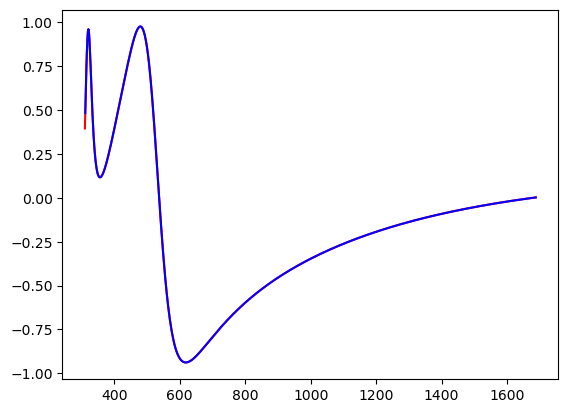

In [60]:
plt.plot(df['Wavelength (nm)'], df['S'], color = 'red')
plt.plot(CE_test1['Wavelength (nm)'], CE_test1['S'], color = 'blue')

# Now that the through the glass SE is working, the linear gradient will now be developed

In [6]:
# Set up 

# Step 1: Load in the polynomials
from numpy.polynomial import Polynomial

# Change directory 
os.chdir(r'C:\Users\bordo\Desktop\Project4\v0.5')
poly = np.load("polynomials.npz")

# Step 2: Assign the polynomials to each parameter 

CPPB1_A = Polynomial(poly['CPPB1_A'])
CPPB1_Br = Polynomial(poly['CPPB1_Br'])
CPPB1_En = Polynomial(poly['CPPB1_En'])
CPPB1_T1 = Polynomial(poly['CPPB1_T1'])
CPPB1_T2 = Polynomial(poly['CPPB1_T2'])
CPPB1_T3 = Polynomial(poly['CPPB1_T3'])

CPPB2_A = Polynomial(poly['CPPB2_A'])
CPPB2_Br = Polynomial(poly['CPPB2_Br'])
CPPB2_En = Polynomial(poly['CPPB2_En'])
CPPB2_T = Polynomial(poly['CPPB2_T1'])

CPPB3_A = Polynomial(poly['CPPB3_A'])
CPPB3_Br = Polynomial(poly['CPPB3_Br'])
CPPB3_En = Polynomial(poly['CPPB3_En'])
CPPB3_T = Polynomial(poly['CPPB3_T1'])

CPPB4_A = Polynomial(poly['CPPB4_A'])
CPPB4_Br = Polynomial(poly['CPPB4_Br'])
CPPB4_En = Polynomial(poly['CPPB4_En'])
CPPB4_T = Polynomial(poly['CPPB4_T1'])

CPPB5_A = Polynomial(poly['CPPB5_A'])
CPPB5_Br = Polynomial(poly['CPPB5_Br'])
CPPB5_En = Polynomial(poly['CPPB5_En'])
CPPB5_T = Polynomial(poly['CPPB5_T1'])

CPPB6_A = Polynomial(poly['CPPB6_A'])
CPPB6_Br = Polynomial(poly['CPPB6_Br'])
CPPB6_En = Polynomial(poly['CPPB6_En'])
CPPB6_T = Polynomial(poly['CPPB6_T1'])

CPPB7_A = Polynomial(poly['CPPB7_A'])
CPPB7_Br = Polynomial(poly['CPPB7_Br'])
CPPB7_En = Polynomial(poly['CPPB7_En'])
CPPB7_T = Polynomial(poly['CPPB7_T1'])

CPPB8_A = Polynomial(poly['CPPB8_A'])

CPPB9_A = Polynomial(poly['CPPB9_A'])
CPPB9_Br = Polynomial(poly['CPPB9_Br'])
CPPB9_En = Polynomial(poly['CPPB9_En'])
CPPB9_T = Polynomial(poly['CPPB9_T1'])

CPPB10_A = Polynomial(poly['CPPB10_A'])

TL_Amplitude = Polynomial(poly['TL_Amp'])
TL_Broadening =  Polynomial(poly['TL_Br'])

Urbach_Energy =  Polynomial(poly['Eu'])

Sellmeier_Amp = Polynomial(poly['AUV'])

## Define any polynomial models
def piecewise_poly_CPPB8_A(x):

    return np.piecewise(
    x,
    [x >= 0.85, x < 0.85],
    [CPPB8_A,  0 ] )


def piecewise_poly_CPPB10_A(x):

    return np.piecewise(
    x,
    [x >= 0.85, x < 0.85],
    [CPPB10_A,  0 ])


# Step 3: Define the EMA portion of the model that is used in the transition from Zinc Blende to Wurtzite

# lOAD IN Se46 and Se62
os.chdir(r'C:\Users\bordo\Desktop\Project4\v0.5\OpProps')

Se46 = pd.read_csv('Se46.csv') 
Se46["N"] = Se46["N"].astype(complex)

Se62 = pd.read_csv('Se62.csv') 
Se62["N"] = Se62["N"].astype(complex)

def EMA_Model(x):

    # Check that x is in right spot 
    if x < 0.62 and x > 0.46: 

        # Calculate f
        
        f = (6.25 * x) - 2.875

        # calculate df

        #print(f)
        
        df = Bruggeman_EMA_Roussel(Se46, Se62, f )

        # return df 

        return(df)

    
    else:

        print('X is out of range')
        return()



# Step 4: define the composition model

def CST_Composition_Model(E, *params):

    """
    The goal of the function is to generate the appropriate optical properties for a given Te content (x).
    The optical properties being for a CdTeSe alloy. 

    Currently  0.54 <= x <= 1

    params should only contain a single number, composition x
    """

    # Step 1: Get x

    x = params[0]

    # Set lower limit
    if x < 0: 
        x = 0.00
    # set upper limit
    if x >= 1:
        x = 1.00

    # Step 2: See if x is in EMA region
    
    if x < 0.62 and x > 0.46: 
        #print('x: ', x)

        # Step 2.5 Calculate x if it is in EMA region
        df = EMA_Model(x)
        return(df)


    if x <= 0.46:   # If x is in Zinc Blende region

        #print('x: ', x)
        # Step 2: Generate values 
    
        #print(x)
        A1 = CPPB1_A(x)
        Br1 = CPPB1_Br(x)
        En1 = CPPB1_En(x)
        T1 = CPPB1_T1(x)
    
        A2 = CPPB2_A(x)
        Br2 = CPPB2_Br(x)
        En2 = CPPB2_En(x)
        T2 = CPPB2_T(x)
    
        A3 = CPPB3_A(x)
        Br3 = CPPB3_Br(x)
        En3 = CPPB3_En(x)
        T3 = CPPB3_T(x)
    
        A4 = CPPB4_A(x)
        Br4 = CPPB4_Br(x)
        En4 = CPPB4_En(x)
        T4 = CPPB4_T(x)
    
        A5 = CPPB5_A(x)
        Br5 = CPPB5_Br(x)
        En5 = CPPB5_En(x)
        T5 = CPPB5_T(x)
        
        # Non CPPB terms 
    
        TL_Amp = TL_Amplitude(x)
        TL_Br = TL_Broadening(x)
        Eu = Urbach_Energy(x)
        Einf = 0
        A_uv = 0
    
        # Step 3: Put parameters in list 
      
        cppb_params = [ 
            A1, T1, Br1, En1, 
            A2, T2, Br2, En2,
            A3, T3, Br3, En3,
            A4, T4, Br4, En4,
            A5, T5, Br5, En5,
            0, 0, 0, 0, # Placeholder for Wurtzite region. Could be removed
            0, 0, 0, 0, #
            0, 0, 0, 0, #
            0, 0, 0, 0, #
            0, 0, 0, 0, # 
            TL_Amp, 6, TL_Br, 
            Eu, 
            Einf, 0, A_uv, 7 
        ]
    
        #print(cppb_params)
    
        # Step 4: Calculate CPPB + Urbach Model
    
        df = get_Excitonic_CPPB_Urbach_TL_Background( E, *cppb_params)
        #print(A_uv)
    
        return(df)



    if x >= 0.62:   # If x is in Wurtzite region

        # Step 2: Generate values 
    
        #print('x: ', x)
        A1 = CPPB1_A(x)
        Br1 = CPPB1_Br(x)
        En1 = CPPB1_En(x)
        T1 = CPPB1_T3(x)
    
        A6 = CPPB6_A(x)
        Br6 = CPPB6_Br(x)
        En6 = CPPB6_En(x)
        T6 = CPPB6_T(x)
    
        A7 = CPPB7_A(x)
        Br7 = CPPB7_Br(x)
        En7 = CPPB7_En(x)
        T7 = CPPB7_T(x)

        A8 = piecewise_poly_CPPB8_A(x)
        Br8 = 0.175172684
        En8 = 4.135628725
        T8 = 0
    
        A9 = CPPB9_A(x)
        Br9 = CPPB9_Br(x)
        En9 = CPPB9_En(x)
        T9 = 0


        A10 = piecewise_poly_CPPB10_A(x)
        Br10 = 0.44383174
        En10 = 5.516866874
        T10 = 0
        
        # Non CPPB terms 
    
        TL_Amp = TL_Amplitude(x)
        TL_Br = TL_Broadening(x)
        Eu = Urbach_Energy(x)
        Einf = 0
        A_uv = 0
    
        # Step 3: Put parameters in list 
      
        cppb_params = [ 
            A1, T1, Br1, En1,
            0, 0, 0, 0, #
            0, 0, 0, 0, #
            0, 0, 0, 0, #
            0, 0, 0, 0, # 
            A6, T6, Br6, En6,
            A7, T7, Br7, En7,
            A8, T8, Br8, En8,
            A9, T9, Br9, En9,
            A10, T10, Br10, En10,  
            TL_Amp, 6, TL_Br, 
            Eu, 
            Einf, 0, A_uv, 7 
        ]
    
        
        #print(cppb_params)
    
        # Step 4: Calculate CPPB + Urbach Model
    
        df = get_Excitonic_CPPB_Urbach_TL_Background( E, *cppb_params)
        #print(A_uv)
    
        return(df )


# Step 5: Now define linear model 

def CST_Composition_Linear_Model(E, thickness, y1, y2, Einf = 0.0, Auv = 0.0 ):

    sub_layers = 10
    #print(sub_layers)

    # Step 1 get thickness (already passed in this function)

    # Step 2: get coupled composition values (also already passed in this function: y1 and y2 in this case) 

    # Step 3: calculate line
    x1 = 0 # x-axis is layer thickness. 
    x2 = thickness # line over the thickness of the film 

    m = (y2 - y1) / x2 # caLculate slope of line

    b = y1 # calculate intercept (always y1)

    # Step 4: subdivide thicknesses into 10 layers and cacluate Se content for each one. 

    t = thickness / sub_layers

    comps = [] # store the compositions for each sublayer
    for i in range(sub_layers):

        # determine thickness to do composition calculation

        x = ((1 + 2*i) / 2) * t
        y = m*x + b
        comps.append(y)

    # Step 5: Calculate epsilon for each layer using composition model

    #print(comps)
    eps = []
    thicknessess = []
    for i in range(sub_layers):

        # get df from composition model
        params = [comps[i]]
        df = CST_Composition_Model(E, *params)

        # add Einf to e1

        #test = Einfs[i]
        #print(test)
        
        #df['e1'] = df['e1'].to_numpy() + Einfs[i]

        S = Sellmeier(0, A_uv, 7, Einf, E)
        df_list = [df, S]
        df = sumosscilator(df_list)

        # put df in list 

        eps.append(df)

        # put thickness in list 

        thicknessess.append(t)


    return(eps, thicknessess)


In [7]:
Einfs = 1
A_uv = 20
eps, thick = CST_Composition_Linear_Model(E, 1000, 0.0, 0.5, Einfs, A_uv)

Text(0, 0.5, '$\\epsilon_1$')

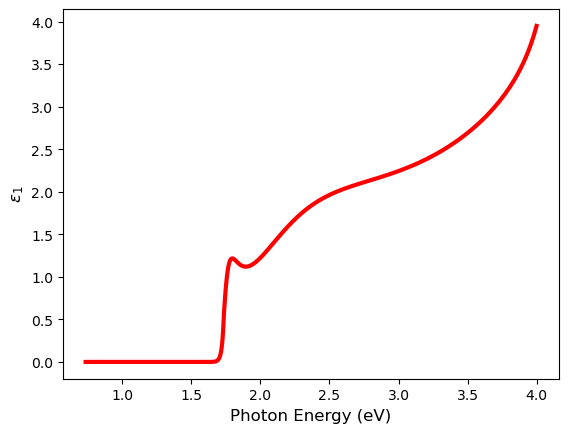

In [8]:
params = [1]
df = CST_Composition_Model(E, *params)

plt.plot(E, df['e2'], label='Polynomial Model', color='red', linewidth=3)
plt.xlabel("Photon Energy (eV)", fontsize=12)
plt.ylabel(r"$\epsilon_1$", fontsize=12)

## In this next section, we will make a program that can generate the SE data for ML training

In [9]:
def SE_TTG_CST_DataSim(num_files):

    for i in range(num_files):
    
        # S1: Define the fit parameters 
        
        Fit_params = {
        'SnO2F1_Einf': random.randrange(200, 400) / 100, # range from 2.00 to 4.00
        'SnO2F2_Einf': random.randrange(200, 400) / 100, # range from 2.00 to 4.00
        'HRT1_Einf': random.randrange(300, 600) / 100, # range from 3.00 to 6.00
        'HRT2_Einf': random.randrange(300, 700) / 100, # range from 3.00 to 7.00
        'CST1_Thickness': random.randrange(500, 5000) / 10 , # range from 50 to 500 nm
        'CST1_Einf': random.randrange(0, 200) / 100, # range from 1.00 to 2.00
        'CST1_Auv': random.randrange(0, 300) / 10, # range from 0 to 30  
        'CST1_Composition': random.randrange(10, 100) / 100, # range from 0.1 to 1.0    
        'CST_Gradient_Thickness': random.randrange(500, 15000) / 10 , # range from 50 to 1500 nm
        'CST_Gradient_Einf': random.randrange(0, 200) / 100, # range from 1.00 to 2.00 
        'CST_Gradient_Auv': random.randrange(0, 300) / 10, # range from 0 to 30  
        'CST2_Thickness': random.randrange(5000, 20000) / 10 , # range from 500 to 2000 nm  ## Pure CdTe for this iteration, no composition parameter
        'CST2_Einf': random.randrange(0, 200) / 100, # range from 1.00 to 2.00
        'CST2_Auv': random.randrange(0, 300) / 10, # range from 0 to 30    
        'SL1_Thickness': random.randrange(150, 1000) / 10 , # range from 15 to 100 nm
        'SL1_Fraction':  random.randrange(5, 50) / 100 , # range from 0.05 to 0.50 nm
        }
    
    
        # S2: Build Optical Layers 
    
        ####---SnO2F1 Defined---####
    
        drude_params = np.array([ 0.0009722, 2.463])
        L_params = np.array([11.556313, 0.4392, 5.509])
    
        df1 = drude(E, *drude_params)
        df2 = Lorentz(E, *L_params)
        df3 = Sellmeier( 0, 0, 7, Fit_params['SnO2F1_Einf'], E)
        SnO2F1 = sumosscilator([df1, df2, df3])
    
        ####---SnO2F2 Defined---####
    
        drude_params = np.array([ 0.000325, 2.463])
        L_params = np.array([11.556313, 0.4392, 5.509])
    
        df1 = drude(E, *drude_params)
        df2 = Lorentz(E, *L_params)
        df3 = Sellmeier( 0, 0, 7, Fit_params['SnO2F2_Einf'], E)
        SnO2F2 = sumosscilator([df1, df2, df3])

        #Sellmeier(A_ir, A_uv, E_uv, E_inf, E)
    
        ####---HRT1 Defined---####
    
        L_params = np.array([
            7.241792, # A1
            0.7181, # Br1
            5.643, # E1
        
            0.787962, # A2
            0.4610, # Br2
            4.430, # E2
        
            0.122461, # A3
            0.0619, # Br3
            0.788, # E3
            ])
    
        df1 = Lorentz(E, *L_params)
        df2 = Sellmeier( 1.5191, 0, 7, Fit_params['HRT1_Einf'], E)
        HRT1 = sumosscilator([df1, df2])
    
    
    
        ####---HRT2 Defined---####
        
        L_params = np.array([1.993443, 1.1512, 5.734 ]) # A1, Br1, En1
        df1 = Lorentz(E, *L_params)
        df2 = Sellmeier( 0.5467, 0, 7, Fit_params['HRT2_Einf'], E)
        HRT2 = sumosscilator([df1, df2])
    
        ####---CST1 Defined---####
        
        params = [Fit_params['CST1_Composition']] 
        df1 = CST_Composition_Model(E, *params)
        df2 = Sellmeier( 0, Fit_params['CST1_Auv'], 7, Fit_params['CST1_Einf'], E)
        CST1 = sumosscilator([df1, df2])
    
        ####---CST2 Defined---####
        
        params = [0] # fixed to 0 to be CdTe Bulk
        df1 = CST_Composition_Model(E, *params)
        df2 = Sellmeier( 0, Fit_params['CST2_Auv'], 7, Fit_params['CST2_Einf'], E)
        CST2 = sumosscilator([df1, df2])
    
        ####---CST_Gradient Defined---####
        
        CST_Gradient, CST_Gradient_thicknesses = CST_Composition_Linear_Model(E, 
        Fit_params['CST_Gradient_Thickness'], 0, Fit_params['CST1_Composition'], Einf = Fit_params['CST_Gradient_Einf'], Auv = Fit_params['CST_Gradient_Auv'])

        CST_Gradient.reverse() # reverse the list
        CST_Gradient_thicknesses.reverse() # reverse the list
        
    
        ####---HRT_CST1_Interface Defined---####
        
        HRT_CST_EMA = Bruggeman_EMA_Roussel(HRT2, CST1, 0.44)
    
        ####---SL1 Defined---####
       
        SL1 = Bruggeman_EMA_Roussel(CST2, Void, Fit_params['SL1_Fraction'])
    
    
        #S3: Define Structural Model 
    
        Structure = [
            SLG, 
            SnO2, 
            SiO2,
            SnO2F1,
            SnO2F2, 
            HRT1, 
            HRT2, 
            HRT_CST_EMA,
            CST1,
            *CST_Gradient,
            CST2, 
            SL1,
            Void
        ]
            
    
        #S4: Define Thicknesses
    
        Thicknesses = np.array([
            31.72, #SnO2 
            33.71, #SiO2
            34.01, #SnO2F1
            244.23, #SnO2F2 
            66.9, #HRT1 
            32.57, #HRT2 
            31.29, #HRT_CST_EMA
            Fit_params['CST1_Thickness'], #CST1
            *CST_Gradient_thicknesses, #CST_Gradient
            Fit_params['CST2_Thickness'], #CST2, 
            Fit_params['SL1_Thickness'], #SL1, 
        ])
    
    
        #S5: Simulate ellipsometric spectra
    
        AOI = 64.930
        df = SE_Sim_TTG(Structure, AOI, Thicknesses, del_Offset = [0,0,0,0], write_data=False, NCS=True)
    
        #S6: Get timestamp and save ellipsometric spectra 
    
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S.%f")
        df.to_csv(timestamp + '.csv', index=False)
    
        #S7: Save fit parameters as JSON file
    
        base_name = timestamp
        json_filename = base_name + ".json"
        with open(json_filename, "w") as f:
            json.dump(Fit_params, f, indent=4)
    


In [11]:
os.chdir(r'C:\Users\bordo\Desktop\Project4\v0.5\Simulated_Data\Training_Set_1')
num_files = 100
SE_TTG_CST_DataSim(num_files)

os.chdir(r'C:\Users\bordo\Desktop\Project4\v0.5\Simulated_Data\Test_Set_1')
num_files = 10
SE_TTG_CST_DataSim(num_files)

os.chdir(r'C:\Users\bordo\Desktop\Project4\v0.5\Simulated_Data\Validation_Set_1')
num_files = 10
SE_TTG_CST_DataSim(num_files)


# One sample trial was done, the parameters are reporduced below along with a recreation in CompleteEASE

In [13]:

# S1: Define the fit parameters 

Fit_params = {  # copy and pasted directly from JSON file
    "SnO2F1_Einf": 2.47,
    "SnO2F2_Einf": 2.92,
    "HRT1_Einf": 5.17,
    "HRT2_Einf": 3.15,
    "CST1_Thickness": 247.0,
    "CST1_Einf": 0.96,
    "CST1_Auv": 10.0,
    "CST1_Composition": 0.51,
    "CST_Gradient_Thickness": 1246.8,
    "CST_Gradient_Einf": 1.67,
    "CST_Gradient_Auv": 27.6,
    "CST2_Thickness": 1975.2,
    "CST2_Einf": 1.85,
    "CST2_Auv": 27.9,
    "SL1_Thickness": 78.1,
    "SL1_Fraction": 0.42
}

# S2: Build Optical Layers 

####---SnO2F1 Defined---####

drude_params = np.array([ 0.0009722, 2.463])
L_params = np.array([11.556313, 0.4392, 5.509])

df1 = drude(E, *drude_params)
df2 = Lorentz(E, *L_params)
df3 = Sellmeier( 0, 0, 7, Fit_params['SnO2F1_Einf'], E)
SnO2F1 = sumosscilator([df1, df2, df3])

####---SnO2F2 Defined---####

drude_params = np.array([ 0.000325, 2.463])
L_params = np.array([11.556313, 0.4392, 5.509])

df1 = drude(E, *drude_params)
df2 = Lorentz(E, *L_params)
df3 = Sellmeier( 0, 0, 7, Fit_params['SnO2F2_Einf'], E)
SnO2F2 = sumosscilator([df1, df2, df3])

#Sellmeier(A_ir, A_uv, E_uv, E_inf, E)

####---HRT1 Defined---####

L_params = np.array([
    7.241792, # A1
    0.7181, # Br1
    5.643, # E1

    0.787962, # A2
    0.4610, # Br2
    4.430, # E2

    0.122461, # A3
    0.0619, # Br3
    0.788, # E3
    ])

df1 = Lorentz(E, *L_params)
df2 = Sellmeier( 1.5191, 0, 7, Fit_params['HRT1_Einf'], E)
HRT1 = sumosscilator([df1, df2])



####---HRT2 Defined---####

L_params = np.array([1.993443, 1.1512, 5.734 ]) # A1, Br1, En1
df1 = Lorentz(E, *L_params)
df2 = Sellmeier( 0.5467, 0, 7, Fit_params['HRT2_Einf'], E)
HRT2 = sumosscilator([df1, df2])

####---CST1 Defined---####

params = [Fit_params['CST1_Composition']] 
df1 = CST_Composition_Model(E, *params)
df2 = Sellmeier( 0, Fit_params['CST1_Auv'], 7, Fit_params['CST1_Einf'], E)
CST1 = sumosscilator([df1, df2])

####---CST2 Defined---####

params = [0] # fixed to 0 to be CdTe Bulk
df1 = CST_Composition_Model(E, *params)
df2 = Sellmeier( 0, Fit_params['CST2_Auv'], 7, Fit_params['CST2_Einf'], E)
CST2 = sumosscilator([df1, df2])

####---CST_Gradient Defined---####

CST_Gradient, CST_Gradient_thicknesses = CST_Composition_Linear_Model(E, 
Fit_params['CST_Gradient_Thickness'], 0, Fit_params['CST1_Composition'], Einf = Fit_params['CST_Gradient_Einf'], Auv = Fit_params['CST_Gradient_Auv'])

CST_Gradient.reverse() # reverse the list
CST_Gradient_thicknesses.reverse() # reverse the list


####---HRT_CST1_Interface Defined---####

HRT_CST_EMA = Bruggeman_EMA_Roussel(HRT2, CST1, 0.44)

####---SL1 Defined---####

SL1 = Bruggeman_EMA_Roussel(CST2, Void, Fit_params['SL1_Fraction'])


#S3: Define Structural Model 

Structure = [
    SLG, 
    SnO2, 
    SiO2,
    SnO2F1,
    SnO2F2, 
    HRT1, 
    HRT2, 
    HRT_CST_EMA,
    CST1,
    *CST_Gradient,
    CST2, 
    SL1,
    Void
]
    

#S4: Define Thicknesses

Thicknesses = np.array([
    31.72, #SnO2 
    33.71, #SiO2
    34.01, #SnO2F1
    244.23, #SnO2F2 
    66.9, #HRT1 
    32.57, #HRT2 
    31.29, #HRT_CST_EMA
    Fit_params['CST1_Thickness'], #CST1
    *CST_Gradient_thicknesses, #CST_Gradient
    Fit_params['CST2_Thickness'], #CST2, 
    Fit_params['SL1_Thickness'], #SL1, 
])


#S5: Simulate ellipsometric spectra

AOI = 64.930
df1 = SE_Sim_TTG(Structure, AOI, Thicknesses, del_Offset = [0,0,0,0], write_data=False, NCS=True)

#S6: Get timestamp and save ellipsometric spectra 

#timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S.%f")
#df.to_csv(timestamp + '.csv', index=False)

#S7: Save fit parameters as JSON file

#base_name = timestamp
#json_filename = base_name + ".json"
#with open(json_filename, "w") as f:
#json.dump(Fit_params, f, indent=4)

# get material files

#os.chdir(r'C:\Users\bordo\Documents\UToledo\Research\ML\Project4\v0.5\Test_Data\CE_Tests\ML_Test1')

"""
for i in range(len(Structure)):

    df = Structure[i]
    df.to_csv('S' + str(i) + '.csv')

"""

In [14]:
# get test from CompleteEASE
os.chdir(r'C:\Users\bordo\Desktop\Project4\v0.5\Test_Data\CE_Tests\ML_Test1') 
file = 'CE_test2.csv'
CE_test2 = pd.read_csv(file)

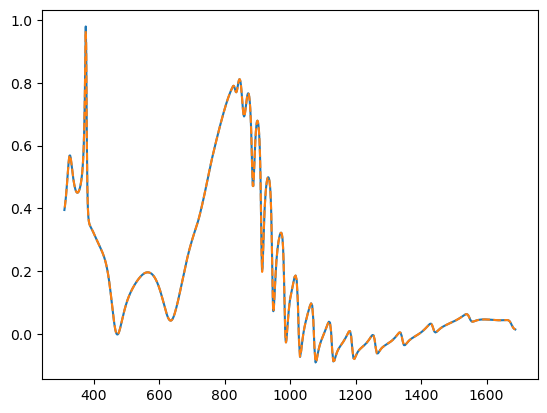

In [16]:
plt.plot(df1['Wavelength (nm)'], df1['N'])
plt.plot(CE_test2['Wavelength (nm)'], CE_test2['N'], linestyle = '--')

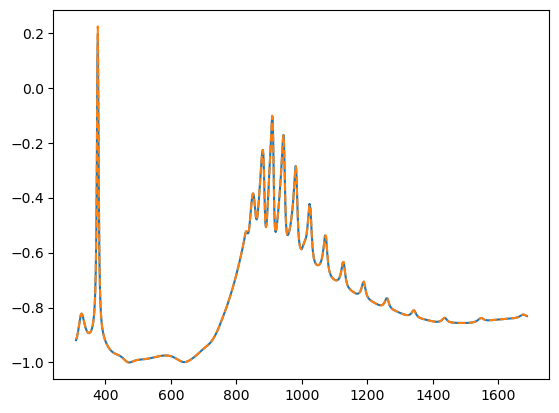

In [17]:
plt.plot(df1['Wavelength (nm)'], df1['C'])
plt.plot(CE_test2['Wavelength (nm)'], CE_test2['C'], linestyle = '--')

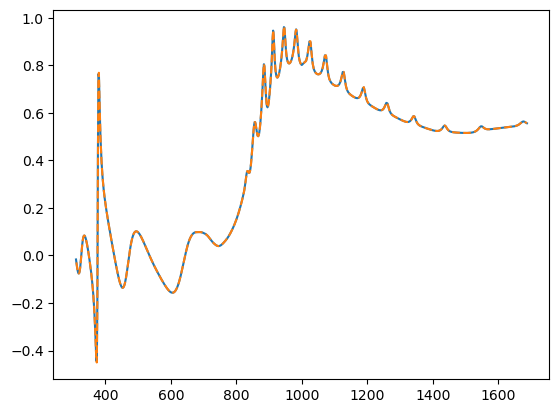

In [18]:
plt.plot(df1['Wavelength (nm)'], df1['S'])
plt.plot(CE_test2['Wavelength (nm)'], CE_test2['S'], linestyle = '--')